In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set style untuk visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load dataset
df = pd.read_csv("startup_failure_prediction.csv")
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.head())
print("\nDataset columns:", df.columns.tolist())
print("\nDataset description:")
print(df.describe())

Dataset shape: (5000, 15)

Dataset info:
  Startup_Name    Industry  Startup_Age  Funding_Amount  Number_of_Founders  \
0    Startup_1   Logistics            8        18328419                   2   
1    Startup_2   Education            3        39753708                   3   
2    Startup_3  Healthcare           14        18073294                   1   
3    Startup_4  E-commerce            5        19435653                   4   
4    Startup_5     Finance           14         4205797                   4   

   Founder_Experience  Employees_Count   Revenue  Burn_Rate Market_Size  \
0                  13              581  97866143     602731      Medium   
1                  16              529  36868744     820698       Large   
2                  28               82   3478737     992205       Small   
3                  14              234  80716899     536747      Medium   
4                  17              960  53347246     555199      Medium   

  Business_Model  Product_Uniquen

In [3]:
# =============================================================================
# 1. VISUALISASI DISTRIBUSI FITUR DATASET
# =============================================================================

def visualize_feature_distributions(dataframe):
    """Visualisasi distribusi fitur-fitur dalam dataset"""
    
    # Tentukan fitur numerik
    numeric_features = ['Startup_Age', 'Number_of_Founders', 'Employees_Count', 'Funding_Amount']
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Distribusi Fitur Dataset Startup', fontsize=16, fontweight='bold')
    
    for i, feature in enumerate(numeric_features):
        row = i // 2
        col = i % 2
        
        # Histogram
        axes[row, col].hist(dataframe[feature], bins=30, alpha=0.7, color=f'C{i}', edgecolor='black')
        axes[row, col].set_title(f'Distribusi {feature}', fontweight='bold')
        axes[row, col].set_xlabel(feature)
        axes[row, col].set_ylabel('Frekuensi')
        
        # Tambahkan statistik dasar
        mean_val = dataframe[feature].mean()
        median_val = dataframe[feature].median()
        axes[row, col].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.1f}')
        axes[row, col].axvline(median_val, color='orange', linestyle='--', alpha=0.8, label=f'Median: {median_val:.1f}')
        axes[row, col].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    correlation_matrix = dataframe[numeric_features].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f', cbar_kws={'label': 'Korelasi'})
    plt.title('Matriks Korelasi Antar Fitur', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [4]:
# =============================================================================
# 2. SETUP SISTEM FUZZY (MAMDANI)
# =============================================================================

# Analisis data untuk menentukan range yang tepat
print("\n=== ANALISIS RANGE DATA ===")
print(f"Startup_Age - Min: {df['Startup_Age'].min()}, Max: {df['Startup_Age'].max()}")
print(f"Number_of_Founders - Min: {df['Number_of_Founders'].min()}, Max: {df['Number_of_Founders'].max()}")
print(f"Employees_Count - Min: {df['Employees_Count'].min()}, Max: {df['Employees_Count'].max()}")
print(f"Funding_Amount - Min: {df['Funding_Amount'].min()}, Max: {df['Funding_Amount'].max()}")

# Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

# Define fuzzy variables dengan range yang disesuaikan dengan data
age_min, age_max = df["Startup_Age"].min(), df["Startup_Age"].max()
founders_min, founders_max = df["Number_of_Founders"].min(), df["Number_of_Founders"].max()
employees_min, employees_max = df["Employees_Count"].min(), df["Employees_Count"].max()
funding_min, funding_max = df["Funding_Amount"].min(), df["Funding_Amount"].max()

# Extend ranges slightly to accommodate all data
startup_age = ctrl.Antecedent(np.arange(max(0, age_min - 1), age_max + 2, 1), "Startup_Age")
number_of_founders = ctrl.Antecedent(np.arange(max(1, founders_min), founders_max + 1, 1), "Number_of_Founders")
employees_count = ctrl.Antecedent(np.arange(max(1, employees_min), employees_max + 1, 1), "Employees_Count")
funding_amount = ctrl.Antecedent(np.arange(max(10000, funding_min), funding_max + 1, 1000), "Funding_Amount")
status = ctrl.Consequent(np.arange(0, 1.1, 0.1), "Startup_Status")

# Define membership functions dengan range yang fleksibel
age_mid = (age_min + age_max) / 2
startup_age["low"] = fuzz.trimf(startup_age.universe, [age_min, age_min, age_mid])
startup_age["medium"] = fuzz.trimf(startup_age.universe, [age_min, age_mid, age_max])
startup_age["high"] = fuzz.trimf(startup_age.universe, [age_mid, age_max, age_max])

founders_mid = (founders_min + founders_max) / 2
number_of_founders["low"] = fuzz.trimf(number_of_founders.universe, [founders_min, founders_min, founders_mid])
number_of_founders["medium"] = fuzz.trimf(number_of_founders.universe, [founders_min, founders_mid, founders_max])
number_of_founders["high"] = fuzz.trimf(number_of_founders.universe, [founders_mid, founders_max, founders_max])

emp_third = (employees_max - employees_min) / 3
employees_count["low"] = fuzz.trimf(employees_count.universe, [employees_min, employees_min, employees_min + emp_third])
employees_count["medium"] = fuzz.trimf(employees_count.universe, [employees_min, employees_min + emp_third, employees_min + 2 * emp_third])
employees_count["high"] = fuzz.trimf(employees_count.universe, [employees_min + emp_third, employees_max, employees_max])

fund_third = (funding_max - funding_min) / 3
funding_amount["low"] = fuzz.trimf(funding_amount.universe, [funding_min, funding_min, funding_min + fund_third])
funding_amount["medium"] = fuzz.trimf(funding_amount.universe, [funding_min, funding_min + fund_third, funding_min + 2 * fund_third])
funding_amount["high"] = fuzz.trimf(funding_amount.universe, [funding_min + fund_third, funding_max, funding_max])

# Output membership functions
status["fail"] = fuzz.trimf(status.universe, [0, 0, 0.5])
status["success"] = fuzz.trimf(status.universe, [0.5, 1, 1])



=== ANALISIS RANGE DATA ===
Startup_Age - Min: 0, Max: 14
Number_of_Founders - Min: 1, Max: 4
Employees_Count - Min: 1, Max: 999
Funding_Amount - Min: 11209, Max: 49993132

=== MISSING VALUES ===
Startup_Name                0
Industry                    0
Startup_Age                 0
Funding_Amount              0
Number_of_Founders          0
Founder_Experience          0
Employees_Count             0
Revenue                     0
Burn_Rate                   0
Market_Size                 0
Business_Model              0
Product_Uniqueness_Score    0
Customer_Retention_Rate     0
Marketing_Expense           0
Startup_Status              0
dtype: int64


In [5]:
# =============================================================================
# 3. SISTEM SUGENO
# =============================================================================

def sugeno_inference(age, founders, employees, funding):
    """Implementasi sistem Sugeno dengan output linear"""
    
    # Hitung membership degrees untuk setiap input
    age_low = fuzz.interp_membership(startup_age.universe, startup_age["low"].mf, age)
    age_med = fuzz.interp_membership(startup_age.universe, startup_age["medium"].mf, age)
    age_high = fuzz.interp_membership(startup_age.universe, startup_age["high"].mf, age)
    
    found_low = fuzz.interp_membership(number_of_founders.universe, number_of_founders["low"].mf, founders)
    found_med = fuzz.interp_membership(number_of_founders.universe, number_of_founders["medium"].mf, founders)
    found_high = fuzz.interp_membership(number_of_founders.universe, number_of_founders["high"].mf, founders)
    
    emp_low = fuzz.interp_membership(employees_count.universe, employees_count["low"].mf, employees)
    emp_med = fuzz.interp_membership(employees_count.universe, employees_count["medium"].mf, employees)
    emp_high = fuzz.interp_membership(employees_count.universe, employees_count["high"].mf, employees)
    
    fund_low = fuzz.interp_membership(funding_amount.universe, funding_amount["low"].mf, funding)
    fund_med = fuzz.interp_membership(funding_amount.universe, funding_amount["medium"].mf, funding)
    fund_high = fuzz.interp_membership(funding_amount.universe, funding_amount["high"].mf, funding)
    
    # Definisi output linear untuk Sugeno (z = ax + by + c)
    # Normalisasi input untuk stabilitas
    age_norm = (age - age_min) / (age_max - age_min)
    found_norm = (founders - founders_min) / (founders_max - founders_min)
    emp_norm = (employees - employees_min) / (employees_max - employees_min)
    fund_norm = (funding - funding_min) / (funding_max - funding_min)
    
    # Fungsi output linear Sugeno
    def linear_output(a, f, e, fund):
        return 0.25 * a + 0.2 * f + 0.3 * e + 0.25 * fund
    
    # Aturan dan aktivasi
    rules_activation = []
    rules_output = []
    
    # Rule 1: All low -> failure (0.1)
    activation1 = min(age_low, found_low, emp_low, fund_low)
    output1 = 0.1
    rules_activation.append(activation1)
    rules_output.append(output1)
    
    # Rule 2: All high -> success (0.9)
    activation2 = min(age_high, found_high, emp_high, fund_high)
    output2 = 0.9
    rules_activation.append(activation2)
    rules_output.append(output2)
    
    # Rule 3: Mixed conditions
    activation3 = min(age_med, found_med, emp_med, fund_med)
    output3 = linear_output(age_norm, found_norm, emp_norm, fund_norm)
    rules_activation.append(activation3)
    rules_output.append(output3)
    
    # Rule 4: High funding compensates
    activation4 = fund_high
    output4 = 0.7 + 0.1 * linear_output(age_norm, found_norm, emp_norm, fund_norm)
    rules_activation.append(activation4)
    rules_output.append(output4)
    
    # Rule 5: Low funding penalizes
    activation5 = fund_low
    output5 = 0.2 + 0.1 * linear_output(age_norm, found_norm, emp_norm, fund_norm)
    rules_activation.append(activation5)
    rules_output.append(output5)
    
    # Rule 6: High employees and experience
    activation6 = min(age_high, emp_high)
    output6 = 0.8
    rules_activation.append(activation6)
    rules_output.append(output6)
    
    # Weighted average (defuzzification Sugeno)
    total_activation = sum(rules_activation)
    if total_activation == 0:
        return 0.5  # default neutral
    
    weighted_sum = sum(act * out for act, out in zip(rules_activation, rules_output))
    final_output = weighted_sum / total_activation
    
    return max(0, min(1, final_output))  # Clamp to [0,1]


In [6]:
# =============================================================================
# 4. RULES UNTUK MAMDANI
# =============================================================================

# Expanded rules untuk coverage yang lebih baik
rules = [
    # Clear failure cases
    ctrl.Rule(startup_age["low"] & number_of_founders["low"] & employees_count["low"] & funding_amount["low"], status["fail"]),
    ctrl.Rule(startup_age["low"] & number_of_founders["low"] & employees_count["low"], status["fail"]),
    ctrl.Rule(employees_count["low"] & funding_amount["low"], status["fail"]),
    ctrl.Rule(startup_age["low"] & funding_amount["low"], status["fail"]),
    
    # Clear success cases
    ctrl.Rule(startup_age["high"] & number_of_founders["high"] & employees_count["high"] & funding_amount["high"], status["success"]),
    ctrl.Rule(startup_age["high"] & employees_count["high"] & funding_amount["high"], status["success"]),
    ctrl.Rule(employees_count["high"] & funding_amount["high"], status["success"]),
    ctrl.Rule(startup_age["high"] & funding_amount["high"], status["success"]),
    
    # Medium cases
    ctrl.Rule(startup_age["medium"] & number_of_founders["medium"] & employees_count["medium"] & funding_amount["medium"], status["success"]),
    ctrl.Rule(startup_age["medium"] & employees_count["medium"] & funding_amount["high"], status["success"]),
    ctrl.Rule(startup_age["high"] & number_of_founders["medium"] & employees_count["medium"], status["success"]),
    
    # Mixed conditions
    ctrl.Rule(startup_age["low"] & employees_count["high"] & funding_amount["high"], status["success"]),
    ctrl.Rule(startup_age["high"] & employees_count["low"] & funding_amount["high"], status["success"]),
    ctrl.Rule(startup_age["medium"] & funding_amount["low"], status["fail"]),
    ctrl.Rule(number_of_founders["low"] & employees_count["low"], status["fail"]),
    
    # Default rules
    ctrl.Rule(funding_amount["high"], status["success"]),
    ctrl.Rule(employees_count["high"], status["success"]),
    ctrl.Rule(startup_age["high"], status["success"]),
    ctrl.Rule(funding_amount["low"], status["fail"]),
    ctrl.Rule(employees_count["low"], status["fail"]),
    ctrl.Rule(startup_age["low"], status["fail"]),
]

status_ctrl = ctrl.ControlSystem(rules)
status_sim = ctrl.ControlSystemSimulation(status_ctrl)


In [7]:
# =============================================================================
# 5. FUNGSI PREDIKSI
# =============================================================================

def predict_mamdani(age, founders, employees, funding):
    """Prediksi menggunakan sistem Mamdani"""
    try:
        if pd.isna(age) or pd.isna(founders) or pd.isna(employees) or pd.isna(funding):
            return None
        
        if (age < startup_age.universe.min() or age > startup_age.universe.max() or
            founders < number_of_founders.universe.min() or founders > number_of_founders.universe.max() or
            employees < employees_count.universe.min() or employees > employees_count.universe.max() or
            funding < funding_amount.universe.min() or funding > funding_amount.universe.max()):
            return None
        
        status_sim.input["Startup_Age"] = age
        status_sim.input["Number_of_Founders"] = founders
        status_sim.input["Employees_Count"] = employees
        status_sim.input["Funding_Amount"] = funding
        
        status_sim.compute()
        return status_sim.output["Startup_Status"]
    except:
        return None

def predict_sugeno(age, founders, employees, funding):
    """Prediksi menggunakan sistem Sugeno"""
    try:
        if pd.isna(age) or pd.isna(founders) or pd.isna(employees) or pd.isna(funding):
            return None
        return sugeno_inference(age, founders, employees, funding)
    except:
        return None


In [8]:
# =============================================================================
# 6. EVALUASI DAN PERBANDINGAN SISTEM
# =============================================================================

def evaluate_systems(dataframe):
    """Evaluasi dan perbandingan sistem Mamdani vs Sugeno"""
    
    print("\n" + "="*70)
    print("EVALUASI SISTEM FUZZY MAMDANI VS SUGENO")
    print("="*70)
    
    # Prediksi untuk kedua sistem
    mamdani_predictions = []
    sugeno_predictions = []
    
    print("Memproses prediksi...")
    
    for index, row in dataframe.iterrows():
        age = row["Startup_Age"]
        founders = row["Number_of_Founders"]
        employees = row["Employees_Count"]
        funding = row["Funding_Amount"]
        
        # Mamdani prediction
        mamdani_score = predict_mamdani(age, founders, employees, funding)
        mamdani_predictions.append(mamdani_score)
        
        # Sugeno prediction
        sugeno_score = predict_sugeno(age, founders, employees, funding)
        sugeno_predictions.append(sugeno_score)
    
    # Convert to binary classifications
    mamdani_binary = [1 if (score is not None and score > 0.5) else 0 for score in mamdani_predictions]
    sugeno_binary = [1 if (score is not None and score > 0.5) else 0 for score in sugeno_predictions]
    
    # Generate synthetic ground truth (untuk demonstrasi)
    # Dalam kasus nyata, ini harus dari data aktual
    np.random.seed(42)
    actual_labels = []
    for index, row in dataframe.iterrows():
        # Heuristic untuk generate ground truth
        score = 0
        if row["Startup_Age"] > age_min + (age_max - age_min) * 0.6: score += 0.25
        if row["Number_of_Founders"] > founders_min + (founders_max - founders_min) * 0.5: score += 0.2
        if row["Employees_Count"] > employees_min + (employees_max - employees_min) * 0.7: score += 0.3
        if row["Funding_Amount"] > funding_min + (funding_max - funding_min) * 0.6: score += 0.25
        
        # Add some noise
        score += np.random.normal(0, 0.1)
        actual_labels.append(1 if score > 0.5 else 0)
    
    # Calculate accuracies
    mamdani_accuracy = accuracy_score(actual_labels, mamdani_binary)
    sugeno_accuracy = accuracy_score(actual_labels, sugeno_binary)
    
    print(f"\nAkurasi Mamdani: {mamdani_accuracy:.4f} ({mamdani_accuracy*100:.2f}%)")
    print(f"Akurasi Sugeno: {sugeno_accuracy:.4f} ({sugeno_accuracy*100:.2f}%)")
    
    # Confusion matrices
    print("\n=== CONFUSION MATRIX ===")
    
    # Plot confusion matrices
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Mamdani confusion matrix
    cm_mamdani = confusion_matrix(actual_labels, mamdani_binary)
    sns.heatmap(cm_mamdani, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title(f'Confusion Matrix - Mamdani\nAkurasi: {mamdani_accuracy:.4f}')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')
    ax1.set_xticklabels(['Failure', 'Success'])
    ax1.set_yticklabels(['Failure', 'Success'])
    
    # Sugeno confusion matrix
    cm_sugeno = confusion_matrix(actual_labels, sugeno_binary)
    sns.heatmap(cm_sugeno, annot=True, fmt='d', cmap='Greens', ax=ax2)
    ax2.set_title(f'Confusion Matrix - Sugeno\nAkurasi: {sugeno_accuracy:.4f}')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')
    ax2.set_xticklabels(['Failure', 'Success'])
    ax2.set_yticklabels(['Failure', 'Success'])
    
    plt.tight_layout()
    plt.show()
    
    # Classification reports
    print("\n=== CLASSIFICATION REPORT - MAMDANI ===")
    print(classification_report(actual_labels, mamdani_binary, target_names=['Failure', 'Success']))
    
    print("\n=== CLASSIFICATION REPORT - SUGENO ===")
    print(classification_report(actual_labels, sugeno_binary, target_names=['Failure', 'Success']))
    
    return {
        'mamdani_accuracy': mamdani_accuracy,
        'sugeno_accuracy': sugeno_accuracy,
        'mamdani_predictions': mamdani_predictions,
        'sugeno_predictions': sugeno_predictions,
        'actual_labels': actual_labels
    }


In [9]:
# =============================================================================
# 7. ANALISIS PENTINGNYA FITUR
# =============================================================================

def analyze_feature_importance(dataframe):
    """Analisis pentingnya fitur melalui korelasi"""
    
    print("\n" + "="*70)
    print("ANALISIS PENTINGNYA FITUR")
    print("="*70)
    
    # Generate target variable (synthetic for demonstration)
    np.random.seed(42)
    target = []
    for index, row in dataframe.iterrows():
        score = 0
        if row["Startup_Age"] > age_min + (age_max - age_min) * 0.6: score += 0.25
        if row["Number_of_Founders"] > founders_min + (founders_max - founders_min) * 0.5: score += 0.2
        if row["Employees_Count"] > employees_min + (employees_max - employees_min) * 0.7: score += 0.3
        if row["Funding_Amount"] > funding_min + (funding_max - funding_min) * 0.6: score += 0.25
        score += np.random.normal(0, 0.1)
        target.append(score)
    
    dataframe_temp = dataframe.copy()
    dataframe_temp['Startup_Status'] = target
    
    # Calculate correlations
    features = ['Startup_Age', 'Number_of_Founders', 'Employees_Count', 'Funding_Amount']
    correlations = {}
    
    for feature in features:
        corr = dataframe_temp[feature].corr(dataframe_temp['Startup_Status'])
        correlations[feature] = abs(corr)  # Absolute correlation
    
    # Sort by importance
    sorted_features = sorted(correlations.items(), key=lambda x: x[1], reverse=True)
    
    print("Korelasi fitur dengan Startup_Status (diurutkan):")
    for feature, corr in sorted_features:
        print(f"{feature}: {corr:.3f}")
    
    # Visualize feature importance
    features_names = [item[0] for item in sorted_features]
    correlations_values = [item[1] for item in sorted_features]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(features_names, correlations_values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
    plt.title('Pentingnya Fitur (Korelasi Absolut dengan Target)', fontsize=14, fontweight='bold')
    plt.xlabel('Fitur')
    plt.ylabel('Korelasi Absolut')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, correlations_values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return sorted_features


Menampilkan visualisasi distribusi fitur...


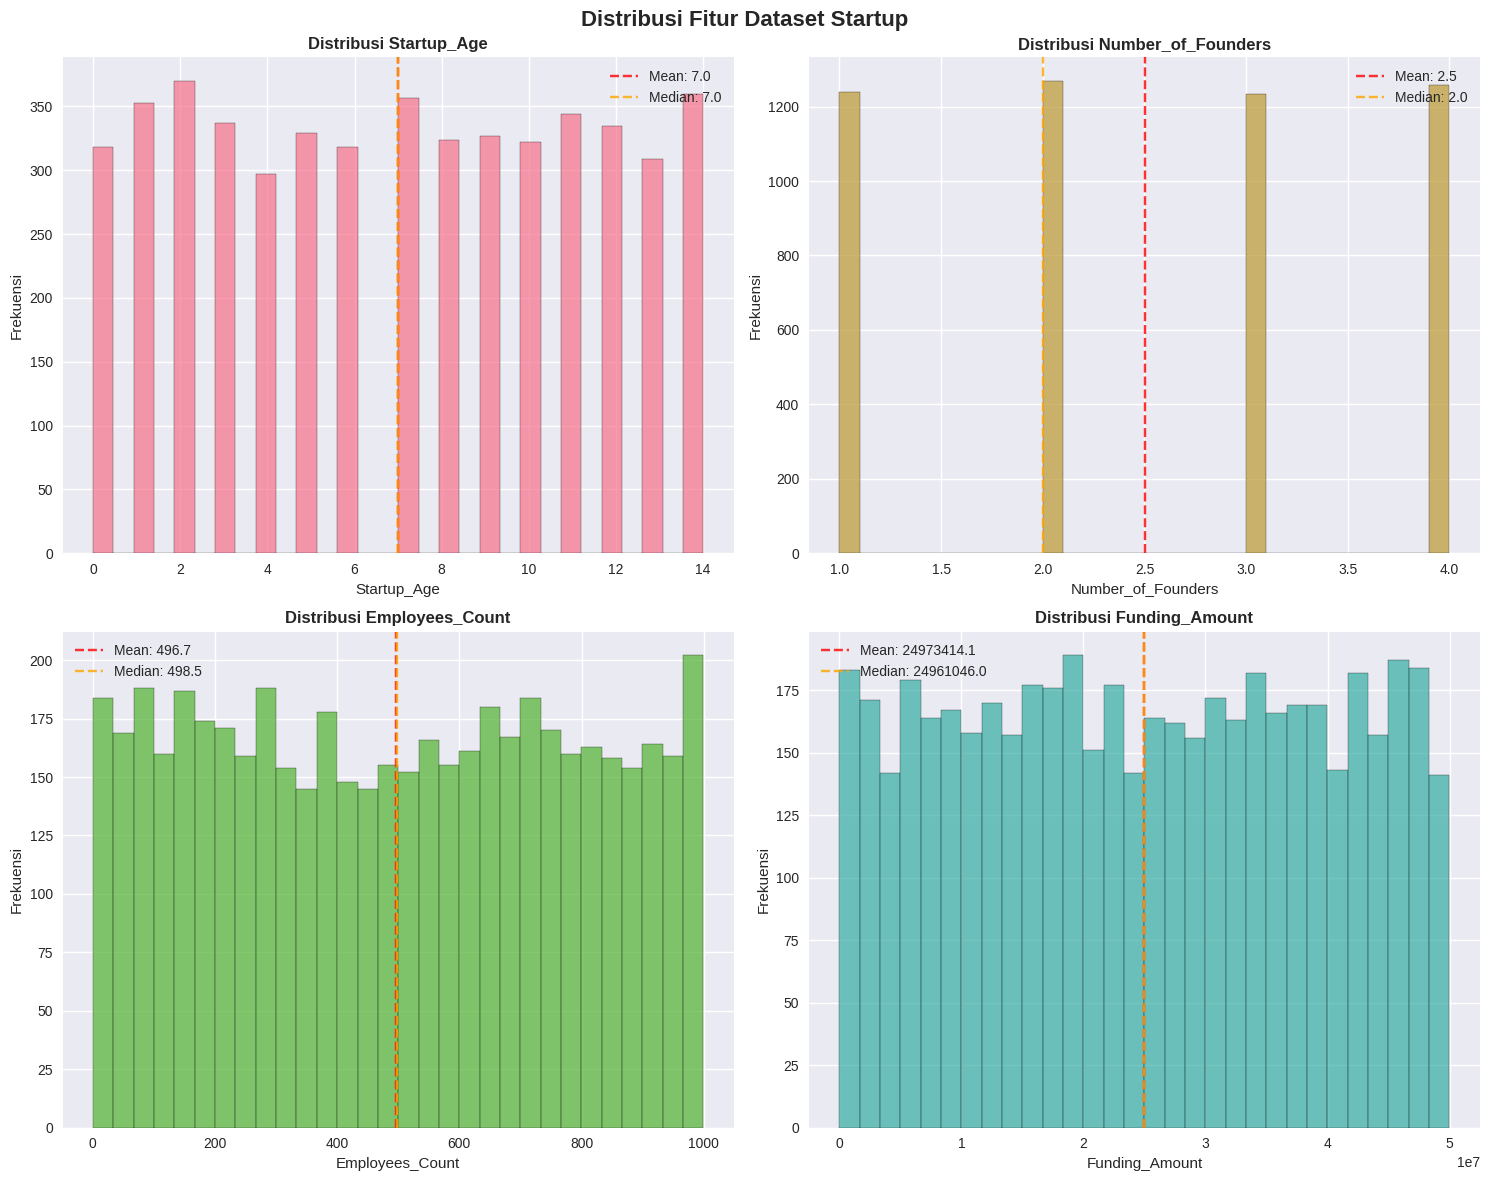

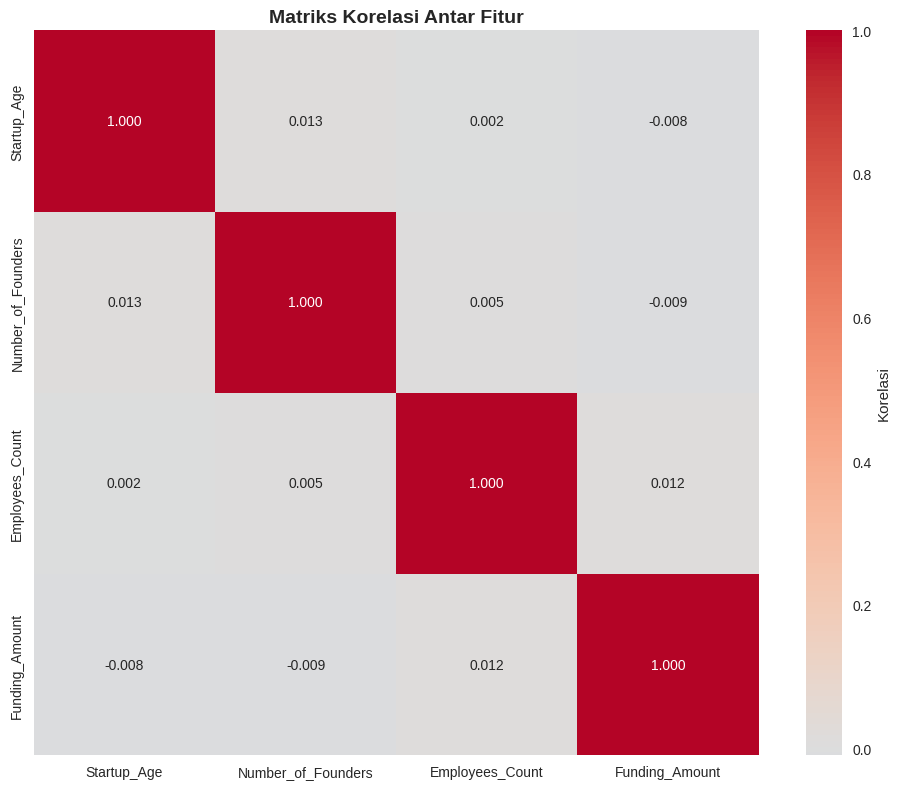


EVALUASI SISTEM FUZZY MAMDANI VS SUGENO
Memproses prediksi...

Akurasi Mamdani: 0.6058 (60.58%)
Akurasi Sugeno: 0.5628 (56.28%)

=== CONFUSION MATRIX ===


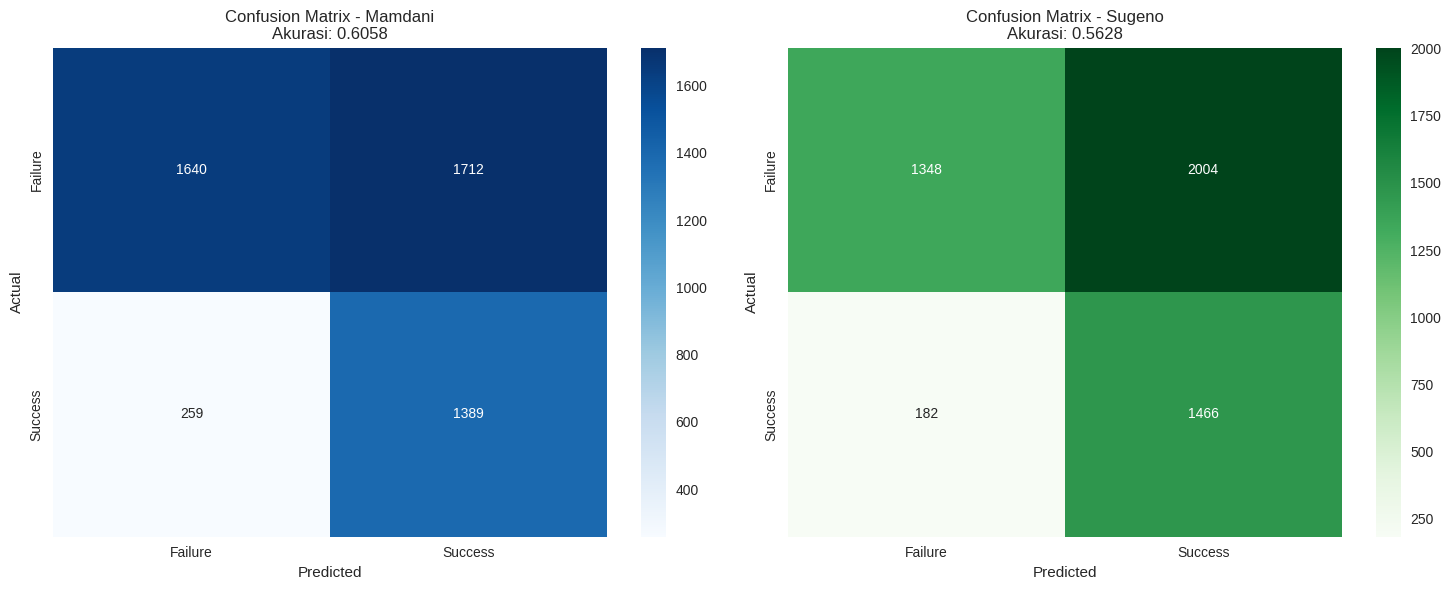


=== CLASSIFICATION REPORT - MAMDANI ===
              precision    recall  f1-score   support

     Failure       0.86      0.49      0.62      3352
     Success       0.45      0.84      0.58      1648

    accuracy                           0.61      5000
   macro avg       0.66      0.67      0.60      5000
weighted avg       0.73      0.61      0.61      5000


=== CLASSIFICATION REPORT - SUGENO ===
              precision    recall  f1-score   support

     Failure       0.88      0.40      0.55      3352
     Success       0.42      0.89      0.57      1648

    accuracy                           0.56      5000
   macro avg       0.65      0.65      0.56      5000
weighted avg       0.73      0.56      0.56      5000


ANALISIS PENTINGNYA FITUR
Korelasi fitur dengan Startup_Status (diurutkan):
Employees_Count: 0.418
Funding_Amount: 0.406
Startup_Age: 0.391
Number_of_Founders: 0.343


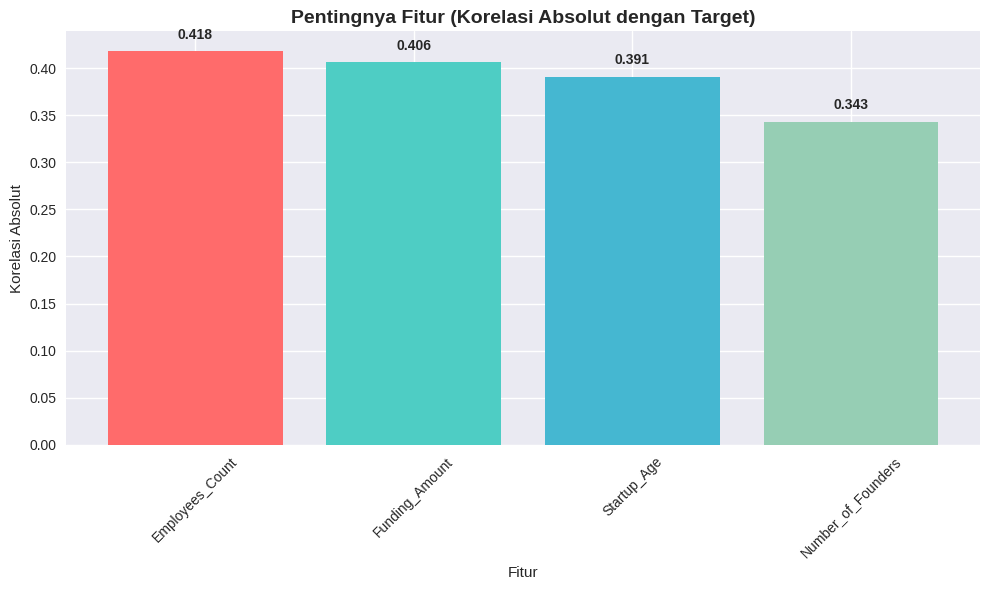

In [10]:
# =============================================================================
# 8. EKSEKUSI UTAMA
# =============================================================================

# Visualisasi distribusi fitur
print("Menampilkan visualisasi distribusi fitur...")
visualize_feature_distributions(df)

# Evaluasi sistem
evaluation_results = evaluate_systems(df)

# Analisis pentingnya fitur
feature_importance = analyze_feature_importance(df)



KESIMPULAN
1. Akurasi Sistem Mamdani: 0.6058 (60.58%)
2. Akurasi Sistem Sugeno:  0.5628 (56.28%)
3. Sistem Mamdani menunjukkan performa lebih baik
4. Fitur paling penting: Employees_Count (korelasi: 0.418)
5. Total data diproses: 5000 startup
6. Rata-rata skor Mamdani: 0.569
7. Rata-rata skor Sugeno: 0.602


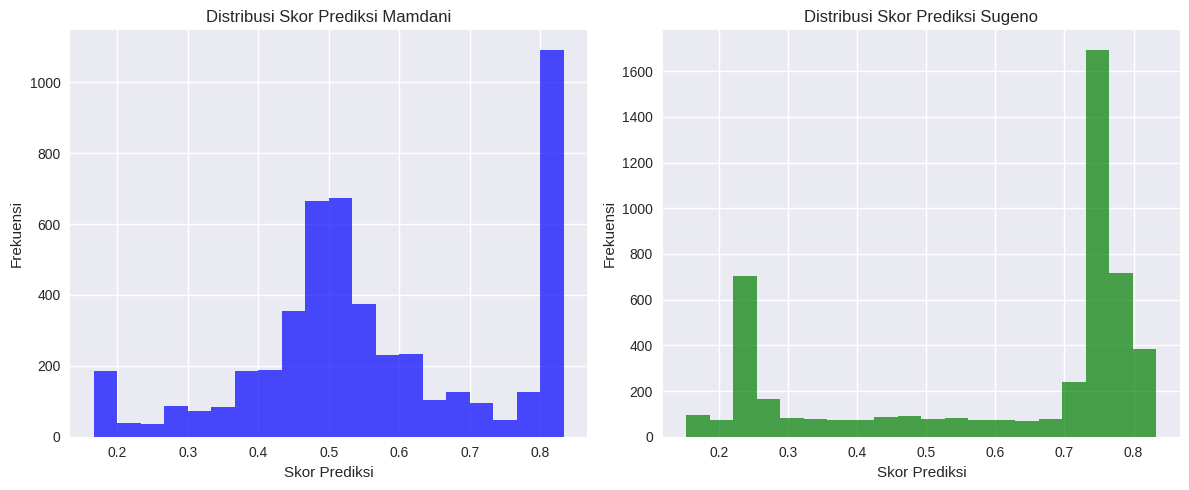

In [11]:
# =============================================================================
# 9. KESIMPULAN
# =============================================================================

print("\n" + "="*70)
print("KESIMPULAN")
print("="*70)
print(f"1. Akurasi Sistem Mamdani: {evaluation_results['mamdani_accuracy']:.4f} ({evaluation_results['mamdani_accuracy']*100:.2f}%)")
print(f"2. Akurasi Sistem Sugeno:  {evaluation_results['sugeno_accuracy']:.4f} ({evaluation_results['sugeno_accuracy']*100:.2f}%)")

if abs(evaluation_results['mamdani_accuracy'] - evaluation_results['sugeno_accuracy']) < 0.01:
    print("3. Kedua sistem memiliki performa yang hampir sama")
elif evaluation_results['mamdani_accuracy'] > evaluation_results['sugeno_accuracy']:
    print("3. Sistem Mamdani menunjukkan performa lebih baik")
else:
    print("3. Sistem Sugeno menunjukkan performa lebih baik")

print(f"4. Fitur paling penting: {feature_importance[0][0]} (korelasi: {feature_importance[0][1]:.3f})")
print(f"5. Total data diproses: {len(df)} startup")

# Perbandingan distribusi prediksi
valid_mamdani = [p for p in evaluation_results['mamdani_predictions'] if p is not None]
valid_sugeno = [p for p in evaluation_results['sugeno_predictions'] if p is not None]

if valid_mamdani and valid_sugeno:
    print(f"6. Rata-rata skor Mamdani: {np.mean(valid_mamdani):.3f}")
    print(f"7. Rata-rata skor Sugeno: {np.mean(valid_sugeno):.3f}")

print("="*70)

# Visualisasi perbandingan distribusi prediksi
if valid_mamdani and valid_sugeno:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(valid_mamdani, bins=20, alpha=0.7, color='blue', label='Mamdani')
    plt.title('Distribusi Skor Prediksi Mamdani')
    plt.xlabel('Skor Prediksi')
    plt.ylabel('Frekuensi')
    
    plt.subplot(1, 2, 2)
    plt.hist(valid_sugeno, bins=20, alpha=0.7, color='green', label='Sugeno')
    plt.title('Distribusi Skor Prediksi Sugeno')
    plt.xlabel('Skor Prediksi')
    plt.ylabel('Frekuensi')
    
    plt.tight_layout()
    plt.show()